In [19]:
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from torchvision import transforms

import matplotlib.pyplot as plt

Код я реализован под Kaggle Notebook, потому что в нем удобно использовать датасеты. 

Перед реализацией кода скачайте самостоятельно датасет https://acdc.vision.ee.ethz.ch/rgb_anon_trainvaltest.zip и https://acdc.vision.ee.ethz.ch/gt_trainval.zip с сайта https://acdc.vision.ee.ethz.ch/download 

Либо можно добавить в свой проект в кагле input dataset https://www.kaggle.com/datasets/shaikhieverik/acdc-dataset

In [20]:
DATA_ROOT = Path("/kaggle/input/datasets/shaikhieverik/acdc-dataset")

GT_ROOT = DATA_ROOT / "gt_trainval" / "gt"
RGB_ROOT = DATA_ROOT / "rgb_anon_trainvaltest" / "rgb_anon"

path_check = pd.DataFrame({
    "path": ["DATA_ROOT", "GT_ROOT", "RGB_ROOT"],
    "exists": [DATA_ROOT.exists(), GT_ROOT.exists(), RGB_ROOT.exists()],
    "value": [DATA_ROOT, GT_ROOT, RGB_ROOT],
})

display(path_check)


,path,exists,value
0,DATA_ROOT,True,/kaggle/input/datasets/shaikhieverik/acdc-dataset
1,GT_ROOT,True,/kaggle/input/datasets/shaikhieverik/acdc-data...
2,RGB_ROOT,True,/kaggle/input/datasets/shaikhieverik/acdc-data...


In [21]:
rgb_files = sorted(RGB_ROOT.rglob("*_rgb_anon.png"))

print("RGB files found:", len(rgb_files))
print("Example RGB file:", rgb_files[0] if rgb_files else "no files found")


RGB files found: 4006
Example RGB file: /kaggle/input/datasets/shaikhieverik/acdc-dataset/rgb_anon_trainvaltest/rgb_anon/fog/test/GOPR0475/GOPR0475_frame_000247_rgb_anon.png


# Head 1: Weather classification

In this head we solve a 4-class image classification task:
`RGB image -> fog / night / rain / snow`.

ACDC contains three official splits: `train`, `val`, and `test`. The official `test` split does not have labels, so we do not use it for training, validation, or final metric calculation.

Our split logic is:

1. `official train` -> `train_split_df` + `val_split_df`
   - `train_split_df` is used for model training.
   - `val_split_df` is an internal validation set used during training for monitoring quality and selecting the best checkpoint.
   - The split is stratified by `weather_id`, so all weather classes keep approximately the same proportions.

2. `official val` -> `test_split_df`
   - `test_split_df` is kept untouched until the final evaluation.
   - It should not be used for choosing hyperparameters or selecting the best checkpoint.

The DataFrame stores only image paths and labels. Images are loaded lazily inside `ACDCWeatherDataset.__getitem__`.


In [22]:
WEATHER_TO_ID = {
    "fog": 0,
    "night": 1,
    "rain": 2,
    "snow": 3,
}

ID_TO_WEATHER = {v: k for k, v in WEATHER_TO_ID.items()}

rows = []
OFFICIAL_SPLITS_FOR_HEAD1 = ["train", "val"]

for weather_name, weather_id in WEATHER_TO_ID.items():
    for official_split in OFFICIAL_SPLITS_FOR_HEAD1:
        split_dir = RGB_ROOT / weather_name / official_split

        if not split_dir.exists():
            print(f"WARNING: folder not found: {split_dir}")
            continue

        for img_path in sorted(split_dir.rglob("*_rgb_anon.png")):
            rows.append({
                "image_path": str(img_path),
                "weather_label": weather_name,
                "weather_id": weather_id,
                "official_split": official_split,
            })

df = pd.DataFrame(rows)

print("Head 1 labeled images:", len(df))
display(pd.crosstab(df["weather_label"], df["official_split"]))
display(df.head(3))


Head 1 labeled images: 2006


official_split,train,val
weather_label,,
fog,400,100
night,400,106
rain,400,100
snow,400,100


,image_path,weather_label,weather_id,official_split
0,/kaggle/input/datasets/shaikhieverik/acdc-data...,fog,0,train
1,/kaggle/input/datasets/shaikhieverik/acdc-data...,fog,0,train
2,/kaggle/input/datasets/shaikhieverik/acdc-data...,fog,0,train


In [23]:
from sklearn.model_selection import train_test_split

# Official train is the only source for model fitting and checkpoint selection.
full_train_df = df[df["official_split"] == "train"].copy().reset_index(drop=True)

# Official val has labels, so we keep it as the final test set.
test_split_df = df[df["official_split"] == "val"].copy().reset_index(drop=True)

train_split_df, val_split_df = train_test_split(
    full_train_df,
    test_size=0.2,
    random_state=42,
    stratify=full_train_df["weather_id"],
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)
test_split_df = test_split_df.reset_index(drop=True)

train_split_df["split"] = "train"
val_split_df["split"] = "val"
test_split_df["split"] = "test"

head1_df = pd.concat([train_split_df, val_split_df, test_split_df], ignore_index=True)

metadata_dir = Path("/kaggle/working/metadata")
metadata_dir.mkdir(parents=True, exist_ok=True)

train_split_df.to_csv(metadata_dir / "head1_weather_train.csv", index=False)
val_split_df.to_csv(metadata_dir / "head1_weather_val.csv", index=False)
test_split_df.to_csv(metadata_dir / "head1_weather_test.csv", index=False)
head1_df.to_csv(metadata_dir / "head1_weather_train_val_test.csv", index=False)

print("Head 1 split sizes:")
display(head1_df["split"].value_counts().reindex(["train", "val", "test"]))

print("Head 1 weather distribution:")
display(pd.crosstab(head1_df["weather_label"], head1_df["split"]))

print("Metadata saved to:", metadata_dir)


Head 1 split sizes:


split
train    1280
val       320
test      406
Name: count, dtype: int64

Head 1 weather distribution:


split,test,train,val
weather_label,,,
fog,100,320,80
night,106,320,80
rain,100,320,80
snow,100,320,80


Metadata saved to: /kaggle/working/metadata


In [24]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class ACDCWeatherDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["image_path"]
        weather_id = int(row["weather_id"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        weather_id = torch.tensor(weather_id, dtype=torch.long)

        return image, weather_id


In [25]:
train_dataset = ACDCWeatherDataset(train_split_df, transform=train_transform)
val_dataset = ACDCWeatherDataset(val_split_df, transform=eval_transform)
test_dataset = ACDCWeatherDataset(test_split_df, transform=eval_transform)

print("Head 1 dataset sizes:")
print("train:", len(train_dataset), "val:", len(val_dataset), "test:", len(test_dataset))


Head 1 dataset sizes:
train: 1280 val: 320 test: 406


In [26]:
image_tensor, weather_id = train_dataset[0]

print("Single Head 1 sample:", image_tensor.shape, image_tensor.dtype, weather_id, weather_id.dtype)


Single Head 1 sample: torch.Size([3, 224, 224]) torch.float32 tensor(3) torch.int64


In [27]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


In [28]:
def summarize_classification_batch(name, loader):
    images, labels = next(iter(loader))
    print(f"{name}: images {tuple(images.shape)} {images.dtype}; labels {tuple(labels.shape)} {labels.dtype}")


summarize_classification_batch("Head 1 train", train_loader)
summarize_classification_batch("Head 1 val", val_loader)
summarize_classification_batch("Head 1 test", test_loader)


Head 1 train: images (32, 3, 224, 224) torch.float32; labels (32,) torch.int64
Head 1 val: images (32, 3, 224, 224) torch.float32; labels (32,) torch.int64
Head 1 test: images (32, 3, 224, 224) torch.float32; labels (32,) torch.int64


## Head 1 data summary

Head 1 prepares data for weather classification: `RGB image -> weather class`.

How labels are obtained:

- ACDC folder name gives the weather label: `fog`, `night`, `rain`, `snow`.
- We map these labels to integer ids with `WEATHER_TO_ID`.
- The model target is one integer class id per image.

Split logic:

- `official train` is split into `train_split_df` and `val_split_df`.
- `train_split_df` is used for training.
- `val_split_df` is used for validation during training and best-checkpoint selection.
- `official val` is used as `test_split_df` for final evaluation.
- `official test` is not used because labels are unavailable.

Objects to use later:

- DataFrames: `train_split_df`, `val_split_df`, `test_split_df`.
- Datasets: `train_dataset`, `val_dataset`, `test_dataset`.
- DataLoaders: `train_loader`, `val_loader`, `test_loader`.

Batch format:

```python
images.shape == [batch_size, 3, 224, 224]
labels.shape == [batch_size]
images.dtype == torch.float32
labels.dtype == torch.int64
```

For MambaVision-T / MambaVision-S, use `images` as model input and set the final classifier output size to `4`. The suitable loss is `torch.nn.CrossEntropyLoss()`.


# Head 2: Object presence multi-label classification

The goal of Head 2 is to predict which semantic classes are present in an RGB image.

This is not pixel-wise segmentation. We use the `gt_labelTrainIds` mask only to build an image-level target vector of length 19:

- `target[i] = 1` if class `trainId == i` appears in at least one mask pixel;
- `target[i] = 0` if this class is absent from the image;
- `255` is the ignored label and is not included in the target vector.

The split logic is the same as in Head 1:

1. `official train` -> `head2_train_df` + `head2_val_df`
   - `head2_train_df` is used for training;
   - `head2_val_df` is used for checkpoint selection.

2. `official val` -> `head2_test_df`
   - this is the final test set.

3. `official test` is not used because ground-truth masks are unavailable.


In [29]:
TRAIN_ID_TO_NAME = {
    0: "road",
    1: "sidewalk",
    2: "building",
    3: "wall",
    4: "fence",
    5: "pole",
    6: "traffic light",
    7: "traffic sign",
    8: "vegetation",
    9: "terrain",
    10: "sky",
    11: "person",
    12: "rider",
    13: "car",
    14: "truck",
    15: "bus",
    16: "train",
    17: "motorcycle",
    18: "bicycle",
}

NUM_SEG_CLASSES = len(TRAIN_ID_TO_NAME)
HEAD2_LABEL_COLUMNS = [f"has_{TRAIN_ID_TO_NAME[i].replace(' ', '_')}" for i in range(NUM_SEG_CLASSES)]

print("Head 2 labels:", NUM_SEG_CLASSES)


Head 2 labels: 19


In [30]:
rgb_files = sorted(RGB_ROOT.rglob("*_rgb_anon.png"))
mask_files = sorted(GT_ROOT.rglob("*_gt_labelTrainIds.png"))

print("RGB files:", len(rgb_files))
print("Mask files:", len(mask_files))


RGB files: 4006
Mask files: 2006


In [31]:
def get_acdc_key(path):
    """Key used to match an RGB image with its mask."""
    weather = path.parts[-4]
    official_split = path.parts[-3]
    sequence = path.parts[-2]
    frame = path.name.split("_frame_")[1].split("_")[0]
    return weather, official_split, sequence, frame


def mask_to_multihot(mask_path, num_classes=NUM_SEG_CLASSES):
    """Convert one gt_labelTrainIds mask into a 19-dimensional binary vector."""
    mask = np.array(Image.open(mask_path))
    class_ids = np.unique(mask)

    target = np.zeros(num_classes, dtype=np.float32)
    class_ids = class_ids[(0 <= class_ids) & (class_ids < num_classes)]
    target[class_ids.astype(np.int64)] = 1.0

    return target


# Match RGB and mask files by weather/split/sequence/frame, not by list order.
rgb_index = {get_acdc_key(path): path for path in rgb_files}
mask_index = {get_acdc_key(path): path for path in mask_files}

assert len(rgb_index) == len(rgb_files), "Some RGB files produced duplicate keys."
assert len(mask_index) == len(mask_files), "Some mask files produced duplicate keys."

labeled_keys = sorted(key for key in rgb_index if key[1] in ["train", "val"])
missing_masks = [key for key in labeled_keys if key not in mask_index]
assert len(missing_masks) == 0, f"RGB images without masks: {len(missing_masks)}"

rows = []
for key in labeled_keys:
    weather, official_split, sequence, frame = key
    rgb_path = rgb_index[key]
    mask_path = mask_index[key]
    target = mask_to_multihot(mask_path)

    row = {
        "image_path": str(rgb_path),
        "mask_path": str(mask_path),
        "weather": weather,
        "official_split": official_split,
        "sequence": sequence,
        "frame": frame,
    }

    for column, value in zip(HEAD2_LABEL_COLUMNS, target):
        row[column] = int(value)

    rows.append(row)

head2_df = pd.DataFrame(rows)

print("Head 2 matched RGB-mask pairs:", len(head2_df))
display(pd.crosstab(head2_df["weather"], head2_df["official_split"]))
display(head2_df.head(3))


Head 2 matched RGB-mask pairs: 2006


official_split,train,val
weather,,
fog,400,100
night,400,106
rain,400,100
snow,400,100


,image_path,mask_path,weather,official_split,sequence,frame,has_road,has_sidewalk,has_building,has_wall,...,has_terrain,has_sky,has_person,has_rider,has_car,has_truck,has_bus,has_train,has_motorcycle,has_bicycle
0,/kaggle/input/datasets/shaikhieverik/acdc-data...,/kaggle/input/datasets/shaikhieverik/acdc-data...,fog,train,GOPR0475,000041,1,1,1,1,...,1,1,1,0,1,1,0,0,0,0
1,/kaggle/input/datasets/shaikhieverik/acdc-data...,/kaggle/input/datasets/shaikhieverik/acdc-data...,fog,train,GOPR0475,000049,1,1,1,0,...,0,1,1,0,1,1,0,0,0,0
2,/kaggle/input/datasets/shaikhieverik/acdc-data...,/kaggle/input/datasets/shaikhieverik/acdc-data...,fog,train,GOPR0475,000096,1,1,1,0,...,0,1,1,0,1,0,0,1,0,0


In [32]:
head2_full_train_df = head2_df[head2_df["official_split"] == "train"].copy().reset_index(drop=True)
head2_test_df = head2_df[head2_df["official_split"] == "val"].copy().reset_index(drop=True)

# Keep fog/night/rain/snow balanced in train and internal validation.
head2_train_df, head2_val_df = train_test_split(
    head2_full_train_df,
    test_size=0.2,
    random_state=42,
    stratify=head2_full_train_df["weather"],
)

head2_train_df = head2_train_df.reset_index(drop=True)
head2_val_df = head2_val_df.reset_index(drop=True)
head2_test_df = head2_test_df.reset_index(drop=True)

head2_train_df["split"] = "train"
head2_val_df["split"] = "val"
head2_test_df["split"] = "test"

head2_all_df = pd.concat([head2_train_df, head2_val_df, head2_test_df], ignore_index=True)

metadata_dir = Path("/kaggle/working/metadata")
metadata_dir.mkdir(parents=True, exist_ok=True)

head2_train_df.to_csv(metadata_dir / "head2_presence_train.csv", index=False)
head2_val_df.to_csv(metadata_dir / "head2_presence_val.csv", index=False)
head2_test_df.to_csv(metadata_dir / "head2_presence_test.csv", index=False)
head2_all_df.to_csv(metadata_dir / "head2_presence_train_val_test.csv", index=False)

print("Head 2 split sizes:")
display(head2_all_df["split"].value_counts().reindex(["train", "val", "test"]))

print("Head 2 weather distribution:")
display(pd.crosstab(head2_all_df["weather"], head2_all_df["split"]))

print("Object presence counts by split:")
display(head2_all_df.groupby("split")[HEAD2_LABEL_COLUMNS].sum().T)

print("Metadata saved to:", metadata_dir)


Head 2 split sizes:


split
train    1280
val       320
test      406
Name: count, dtype: int64

Head 2 weather distribution:


split,test,train,val
weather,,,
fog,100,320,80
night,106,320,80
rain,100,320,80
snow,100,320,80


Object presence counts by split:


split,test,train,val
has_road,406,1280,320
has_sidewalk,399,1148,275
has_building,401,1151,284
has_wall,246,805,200
has_fence,231,845,197
has_pole,403,1276,319
has_traffic_light,186,669,161
has_traffic_sign,381,1191,298
has_vegetation,404,1263,315
has_terrain,280,725,174


Metadata saved to: /kaggle/working/metadata


In [33]:
class ACDCObjectPresenceDataset(Dataset):
    def __init__(self, dataframe, label_columns, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        target = row[self.label_columns].to_numpy(dtype=np.float32)
        target = torch.tensor(target, dtype=torch.float32)

        return image, target


head2_train_dataset = ACDCObjectPresenceDataset(head2_train_df, HEAD2_LABEL_COLUMNS, transform=train_transform)
head2_val_dataset = ACDCObjectPresenceDataset(head2_val_df, HEAD2_LABEL_COLUMNS, transform=eval_transform)
head2_test_dataset = ACDCObjectPresenceDataset(head2_test_df, HEAD2_LABEL_COLUMNS, transform=eval_transform)

print("Head 2 dataset sizes:")
print("train:", len(head2_train_dataset), "val:", len(head2_val_dataset), "test:", len(head2_test_dataset))


Head 2 dataset sizes:
train: 1280 val: 320 test: 406


In [34]:
head2_train_loader = DataLoader(
    head2_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

head2_val_loader = DataLoader(
    head2_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

head2_test_loader = DataLoader(
    head2_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


In [35]:
def summarize_multilabel_batch(name, loader):
    images, targets = next(iter(loader))
    print(f"{name}: images {tuple(images.shape)} {images.dtype}; targets {tuple(targets.shape)} {targets.dtype}")


summarize_multilabel_batch("Head 2 train", head2_train_loader)
summarize_multilabel_batch("Head 2 val", head2_val_loader)
summarize_multilabel_batch("Head 2 test", head2_test_loader)


Head 2 train: images (32, 3, 224, 224) torch.float32; targets (32, 19) torch.float32
Head 2 val: images (32, 3, 224, 224) torch.float32; targets (32, 19) torch.float32
Head 2 test: images (32, 3, 224, 224) torch.float32; targets (32, 19) torch.float32


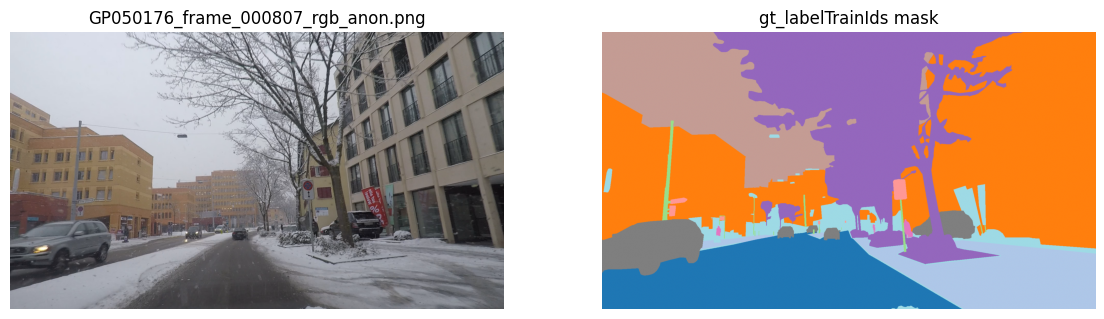

Unique mask values: [  0   1   2   5   7   8  10  11  13 255]
Multi-hot target: [1 1 1 0 0 1 0 1 1 0 1 1 0 1 0 0 0 0 0]
Present classes: ['road', 'sidewalk', 'building', 'pole', 'traffic sign', 'vegetation', 'sky', 'person', 'car']


In [36]:
sample_row = head2_train_df.iloc[0]
sample_image = Image.open(sample_row["image_path"]).convert("RGB")
sample_mask = np.array(Image.open(sample_row["mask_path"]))
sample_target = sample_row[HEAD2_LABEL_COLUMNS].to_numpy(dtype=np.int64)
present_class_names = [TRAIN_ID_TO_NAME[i] for i, value in enumerate(sample_target) if value == 1]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title(Path(sample_row["image_path"]).name)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_mask, cmap="tab20", vmin=0, vmax=18)
plt.title("gt_labelTrainIds mask")
plt.axis("off")

plt.show()

print("Unique mask values:", np.unique(sample_mask))
print("Multi-hot target:", sample_target)
print("Present classes:", present_class_names)


## Head 2 data summary

Head 2 prepares data for object presence multi-label classification: `RGB image -> 19 binary labels`.

How labels are obtained:

- Each RGB image is matched with its `gt_labelTrainIds` mask by `(weather, official_split, sequence, frame)`.
- For every mask we collect unique train ids from `0` to `18`.
- If class `i` appears anywhere in the mask, then `target[i] = 1`; otherwise `target[i] = 0`.
- Mask value `255` is ignored.

Split logic:

- `official train` is split into `head2_train_df` and `head2_val_df`.
- `head2_train_df` is used for training.
- `head2_val_df` is used for validation during training and best-checkpoint selection.
- `official val` is used as `head2_test_df` for final evaluation.
- `official test` is not used because ground-truth masks are unavailable.

Objects to use later:

- DataFrames: `head2_train_df`, `head2_val_df`, `head2_test_df`.
- Datasets: `head2_train_dataset`, `head2_val_dataset`, `head2_test_dataset`.
- DataLoaders: `head2_train_loader`, `head2_val_loader`, `head2_test_loader`.
- Label names: `HEAD2_LABEL_COLUMNS` and `TRAIN_ID_TO_NAME`.

Batch format:

```python
images.shape == [batch_size, 3, 224, 224]
targets.shape == [batch_size, 19]
images.dtype == torch.float32
targets.dtype == torch.float32
```

For MambaVision-T / MambaVision-S, use `images` as model input and set the final classifier output size to `19`. The suitable loss is `torch.nn.BCEWithLogitsLoss()` because this is a multi-label task.
